In [1]:
import numpy as np
import pandas as pd

In [268]:
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv("capstone_phase3_features.csv")
df.head()

,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,...,visit_frequency,avg_length_of_stay_patients,provider_rejection_rate,days_since_registration,visit_month,visit_year,visit_dayofweek,bill_per_hour,unapproved_gap,is_backdated
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,...,2,3.725000,14.865510,65,10,2025,5,5262.723214,23577.0,0
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,...,4,32.025000,15.691534,-206,4,2025,6,2340.833844,0.0,1
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,...,4,20.542500,14.967846,9,7,2025,6,142.505656,0.0,0
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,...,7,28.165714,15.248010,-62,11,2025,2,586.603240,0.0,1
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,...,5,22.988000,14.967846,0,3,2025,5,1524.578178,0.0,0


In [4]:
df.columns


Index(['visit_id', 'patient_id', 'visit_date', 'department', 'visit_type',
       'length_of_stay_hours', 'risk_score', 'doctor_id', 'age', 'gender',
       'city', 'insurance_provider', 'chronic_flag', 'registration_date',
       'bill_id', 'billed_amount', 'approved_amount', 'claim_status',
       'payment_days', 'billing_date', 'visit_frequency',
       'avg_length_of_stay_patients', 'provider_rejection_rate',
       'days_since_registration', 'visit_month', 'visit_year',
       'visit_dayofweek', 'bill_per_hour', 'unapproved_gap', 'is_backdated'],
      dtype='object')

In [5]:
#dropping the ids
df=df.drop(columns=['patient_id','visit_id','bill_id','doctor_id'],axis=1)
df.head(10)

,visit_date,department,visit_type,length_of_stay_hours,risk_score,age,gender,city,insurance_provider,chronic_flag,...,visit_frequency,avg_length_of_stay_patients,provider_rejection_rate,days_since_registration,visit_month,visit_year,visit_dayofweek,bill_per_hour,unapproved_gap,is_backdated
0,2025-10-18,Cardiology,ER,3.48,Low,90,M,Bangalore,CareOne,1,...,2,3.725000,14.865510,65,10,2025,5,5262.723214,23577.0,0
1,2025-04-06,Orthopedics,OPD,15.31,High,30,M,Hyderabad,SecureLife,1,...,4,32.025000,15.691534,-206,4,2025,6,2340.833844,0.0,1
2,2025-07-13,ICU,ER,34.36,Low,25,F,Chennai,HealthPlus,1,...,4,20.542500,14.967846,9,7,2025,6,142.505656,0.0,0
3,2025-11-19,Cardiology,ER,37.89,High,75,M,Delhi,MediCareX,0,...,7,28.165714,15.248010,-62,11,2025,2,586.603240,0.0,1
4,2025-03-29,General,ICU,16.78,Medium,80,M,Bangalore,HealthPlus,1,...,5,22.988000,14.967846,0,3,2025,5,1524.578178,0.0,0
5,2025-12-20,General,OPD,0.70,High,32,M,Bangalore,CareOne,0,...,3,21.033333,14.865510,24,12,2025,5,11443.529412,0.0,0
6,2025-11-12,Cardiology,OPD,6.40,Low,10,F,Bangalore,CareOne,1,...,8,10.225000,14.865510,215,11,2025,2,847.162162,1831.0,0
7,2025-09-18,ER,ICU,26.86,High,65,M,Mumbai,CareOne,0,...,5,20.314000,14.865510,-12,9,2025,3,1370.387653,0.0,1
8,2026-01-17,General,ER,8.31,Medium,51,M,Mumbai,HealthPlus,0,...,7,24.697143,14.967846,183,1,2026,5,2283.458647,0.0,0
9,2025-12-07,ER,ER,23.22,Low,49,F,Delhi,HealthPlus,1,...,9,18.795556,14.967846,157,12,2025,6,749.834847,0.0,0


In [6]:
#converting object to category
df.select_dtypes(include="object").columns

Index(['visit_date', 'department', 'visit_type', 'risk_score', 'gender',
       'city', 'insurance_provider', 'registration_date', 'claim_status',
       'billing_date'],
      dtype='object')

In [7]:
cat_cols=["department", "visit_type", "risk_score", "gender",
       "city", "insurance_provider","claim_status"]
df[cat_cols]=df[cat_cols].astype("category")

In [8]:
df['visit_date'] = pd.to_datetime(df['visit_date'])
df['registration_date'] = pd.to_datetime(df['registration_date'])
df["billing_date"]=pd.to_datetime(df["billing_date"])

In [9]:
df.dtypes

visit_date                     datetime64[ns]
department                           category
visit_type                           category
length_of_stay_hours                  float64
risk_score                           category
age                                     int64
gender                               category
city                                 category
insurance_provider                   category
chronic_flag                            int64
registration_date              datetime64[ns]
billed_amount                         float64
approved_amount                       float64
claim_status                         category
payment_days                          float64
billing_date                   datetime64[ns]
visit_frequency                         int64
avg_length_of_stay_patients           float64
provider_rejection_rate               float64
days_since_registration                 int64
visit_month                             int64
visit_year                        

In [14]:
X=df.drop(columns=['risk_score'],axis=1)

In [15]:
risk_num_cols = [
    "billed_amount",
    "approved_amount",
    "provider_rejection_rate",
    "visit_frequency",
    "avg_length_of_stay_patients",
    "days_since_registration",
    "payment_days",
    "length_of_stay_hours",
    "age",
    "bill_per_hour",
    "unapproved_gap",
    "chronic_flag",     
    "is_backdated"      
]


In [16]:
risk_cat_cols = [
    "gender",
    "department",
    "visit_type"
]


In [17]:
risk_features = risk_num_cols + risk_cat_cols


In [23]:
X_risk = df[risk_features]
y_risk = df["risk_score"]

In [24]:
le_risk = LabelEncoder()
y_risk = le_risk.fit_transform(df["risk_score"])

In [25]:
X_risk = pd.get_dummies(
    X_risk,
    columns=risk_cat_cols,
    drop_first=True
)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_risk,
    y_risk,
    test_size=0.2,
    random_state=42,
    stratify=y_risk
)

In [27]:
scaler = StandardScaler()

X_train[risk_num_cols] = scaler.fit_transform(X_train[risk_num_cols])
X_test[risk_num_cols] = scaler.transform(X_test[risk_num_cols])


In [30]:
log_model = LogisticRegression(
    max_iter=3000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)


In [31]:
log_model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [267]:

y_train_pred = log_model.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

Training Accuracy: 0.3883


In [279]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.21      0.27      0.24      4027
           1       0.52      0.49      0.50      9976
           2       0.33      0.31      0.32      5997

    accuracy                           0.39     20000
   macro avg       0.35      0.35      0.35     20000
weighted avg       0.40      0.39      0.39     20000



In [281]:
#confusion matrix
log_cm_train = confusion_matrix(y_train, y_train_pred)
print(log_cm_train)

[[1092 1805 1130]
 [2566 4843 2567]
 [1505 2661 1831]]


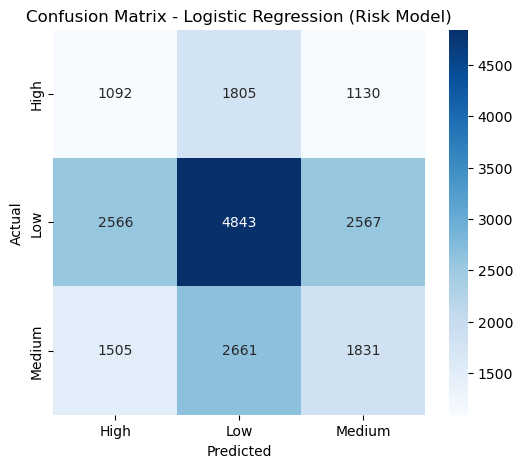

In [283]:
plt.figure(figsize=(6,5))

sns.heatmap(log_cm_train,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_risk.classes_,
            yticklabels=le_risk.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Risk Model)")
plt.show()

In [266]:
y_pred = log_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.3836
              precision    recall  f1-score   support

           0       0.19      0.24      0.21      1007
           1       0.52      0.49      0.51      2494
           2       0.33      0.30      0.32      1499

    accuracy                           0.38      5000
   macro avg       0.35      0.34      0.34      5000
weighted avg       0.40      0.38      0.39      5000



In [269]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[ 238  478  291]
 [ 646 1224  624]
 [ 394  649  456]]


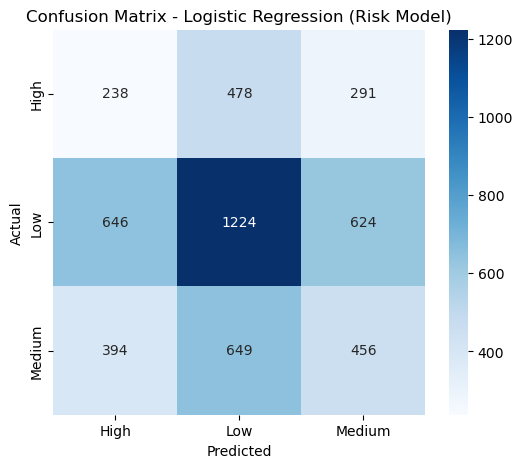

In [270]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_risk.classes_,
            yticklabels=le_risk.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Risk Model)")
plt.show()


In [261]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_split=6,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    bootstrap=False,
    n_jobs=-1
)


In [262]:
rf_model.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,5
,min_samples_split,6
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [327]:

y_train_pred = rf_model.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

Training Accuracy: 0.48285


In [328]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.35      0.25      0.29      4027
           1       0.55      0.64      0.59      9976
           2       0.40      0.37      0.39      5997

    accuracy                           0.48     20000
   macro avg       0.44      0.42      0.42     20000
weighted avg       0.47      0.48      0.47     20000



In [285]:
#confusion matrix
rf_cm_train = confusion_matrix(y_train, y_train_pred)
print(rf_cm_train)


[[1092 1805 1130]
 [2566 4843 2567]
 [1505 2661 1831]]


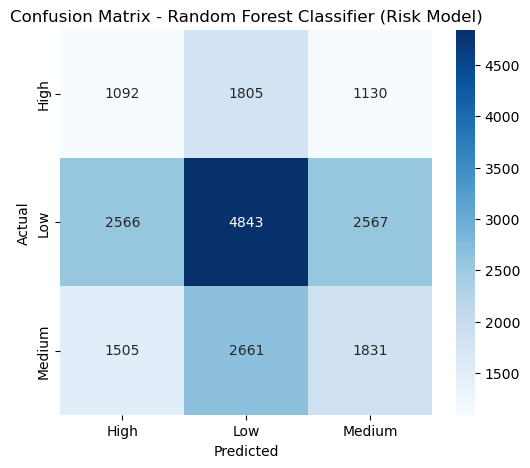

In [286]:
plt.figure(figsize=(6,5))

sns.heatmap(rf_cm_train,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_risk.classes_,
            yticklabels=le_risk.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest Classifier (Risk Model)")
plt.show()

In [264]:
y_pred_rf = rf_model.predict(X_test)

print("RF Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


RF Test Accuracy: 0.4296
              precision    recall  f1-score   support

           0       0.21      0.16      0.18      1007
           1       0.54      0.60      0.57      2494
           2       0.34      0.33      0.33      1499

    accuracy                           0.43      5000
   macro avg       0.36      0.36      0.36      5000
weighted avg       0.41      0.43      0.42      5000



In [272]:
#confusion matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)
print(rf_cm)


[[ 162  516  329]
 [ 372 1497  625]
 [ 248  762  489]]


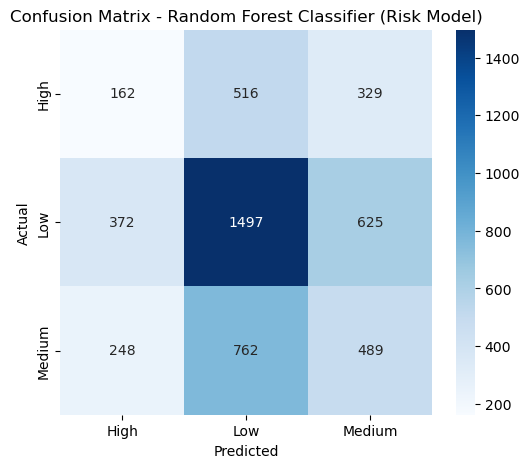

In [273]:
plt.figure(figsize=(6,5))

sns.heatmap(rf_cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_risk.classes_,
            yticklabels=le_risk.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest Classifier (Risk Model)")
plt.show()

In [82]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)


{np.int64(0): np.float64(1.6554920950252463), np.int64(1): np.float64(0.6682705159048383), np.int64(2): np.float64(1.1116669445834029)}


In [83]:
sample_weights = np.array([class_weight_dict[y] for y in y_train])


In [331]:
gb_model=HistGradientBoostingClassifier(
  learning_rate = 0.01,
  max_iter = 400,
  max_depth = 5,
  l2_regularization = 0.8
)

In [332]:
gb_model.fit(X_train, y_train, sample_weight=sample_weights)

,loss,'log_loss'
,learning_rate,0.01
,max_iter,400
,max_leaf_nodes,31
,max_depth,5
,min_samples_leaf,20
,l2_regularization,0.8
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [333]:

y_train_pred = gb_model.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

Training Accuracy: 0.4668


In [334]:
print(classification_report(y_train, y_train_pred))


              precision    recall  f1-score   support

           0       0.30      0.27      0.29      4027
           1       0.56      0.60      0.58      9976
           2       0.39      0.37      0.38      5997

    accuracy                           0.47     20000
   macro avg       0.42      0.42      0.42     20000
weighted avg       0.46      0.47      0.46     20000



In [289]:
#confusion matrix
gb_cm_train= confusion_matrix(y_train, y_train_pred)
print(gb_cm_train)


[[1092 1805 1130]
 [2566 4843 2567]
 [1505 2661 1831]]


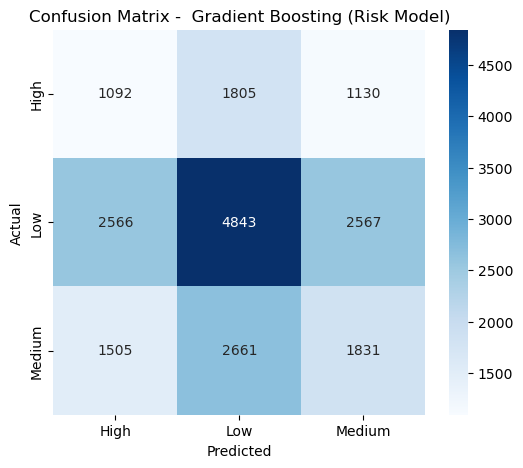

In [290]:
plt.figure(figsize=(6,5))

sns.heatmap(gb_cm_train,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_risk.classes_,
            yticklabels=le_risk.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix -  Gradient Boosting (Risk Model)") 
plt.show()

In [146]:
y_pred_gb = gb_model.predict(X_test)

print("GB Test Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


GB Test Accuracy: 0.4268
              precision    recall  f1-score   support

           0       0.22      0.19      0.21      1007
           1       0.55      0.57      0.56      2494
           2       0.34      0.34      0.34      1499

    accuracy                           0.43      5000
   macro avg       0.37      0.37      0.37      5000
weighted avg       0.42      0.43      0.42      5000



In [275]:
#confusion matrix
gb_cm = confusion_matrix(y_test, y_pred_gb)
print(gb_cm)


[[ 191  485  331]
 [ 378 1428  688]
 [ 280  704  515]]


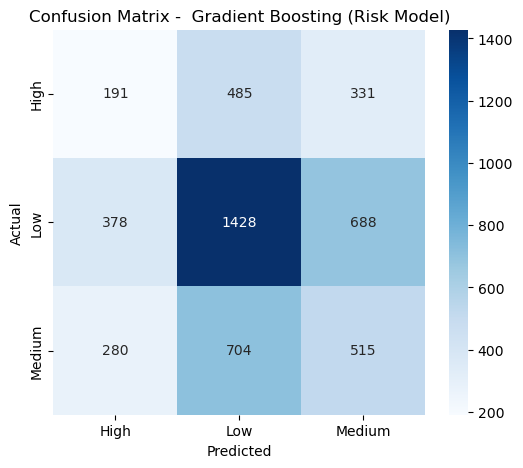

In [276]:
plt.figure(figsize=(6,5))

sns.heatmap(gb_cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_risk.classes_,
            yticklabels=le_risk.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix -  Gradient Boosting (Risk Model)") 
plt.show()

In [151]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)


{np.int64(0): np.float64(1.6554920950252463), np.int64(1): np.float64(0.6682705159048383), np.int64(2): np.float64(1.1116669445834029)}


In [152]:
sample_weights = np.array([class_weight_dict[y] for y in y_train])


In [335]:
from xgboost import XGBClassifier
xgb_model= XGBClassifier(
n_estimators = 350,
learning_rate = 0.03,
max_depth = 2,
subsample = 0.9,
colsample_bytree = 0.5,
reg_lambda = 1,
reg_alpha = 0,
objective = "multi:softprob",
num_class = 3,
eval_metric = "mlogloss")

In [336]:
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [337]:

y_train_pred = xgb_model.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

Training Accuracy: 0.46035


In [338]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.29      0.24      0.26      4027
           1       0.56      0.60      0.58      9976
           2       0.39      0.38      0.38      5997

    accuracy                           0.46     20000
   macro avg       0.41      0.41      0.41     20000
weighted avg       0.45      0.46      0.45     20000



In [295]:
#confusion matrix
xgb_cm_train = confusion_matrix(y_train, y_train_pred)
print(xgb_cm_train)

[[1092 1805 1130]
 [2566 4843 2567]
 [1505 2661 1831]]


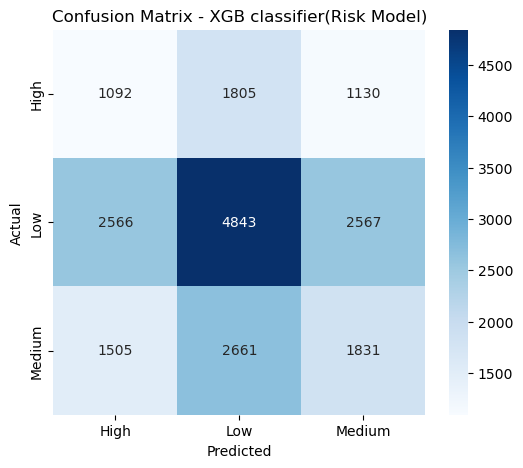

In [296]:
plt.figure(figsize=(6,5))

sns.heatmap(xgb_cm_train,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_risk.classes_,
            yticklabels=le_risk.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGB classifier(Risk Model)") 
plt.show()

In [297]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGB Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGB Test Accuracy: 0.4148
              precision    recall  f1-score   support

           0       0.21      0.19      0.20      1007
           1       0.54      0.56      0.55      2494
           2       0.33      0.33      0.33      1499

    accuracy                           0.41      5000
   macro avg       0.36      0.36      0.36      5000
weighted avg       0.41      0.41      0.41      5000



In [298]:
#confusion matrix
xgb_cm = confusion_matrix(y_test, y_pred_xgb)
print(xgb_cm)


[[ 192  478  337]
 [ 435 1390  669]
 [ 306  701  492]]


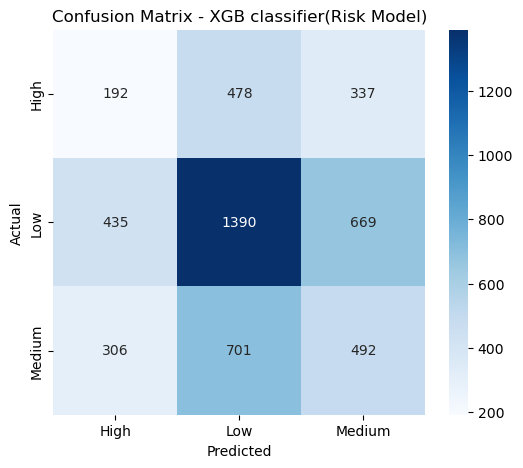

In [299]:
plt.figure(figsize=(6,5))

sns.heatmap(xgb_cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=le_risk.classes_,
            yticklabels=le_risk.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGB classifier(Risk Model)") 
plt.show()

In [301]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# Sort
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

# Show top 10
print(feature_importance_df.head(9))


                        feature  importance
7          length_of_stay_hours    0.344887
9                 bill_per_hour    0.122001
4   avg_length_of_stay_patients    0.098686
0                 billed_amount    0.076396
1               approved_amount    0.065926
5       days_since_registration    0.062192
6                  payment_days    0.057714
10               unapproved_gap    0.046706
8                           age    0.037509


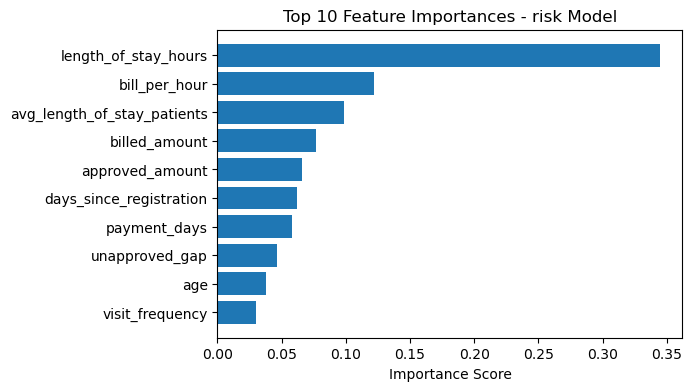

In [312]:
plt.figure(figsize=(6,4))

plt.barh(
    feature_importance_df.head(10)["feature"],
    feature_importance_df.head(10)["importance"]
)

plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - risk Model")
plt.xlabel("Importance Score")
plt.show()


In [313]:
test_original = df.loc[X_test.index].copy()
test_original["actual"] = y_test
test_original["predicted"] = y_pred_rf

In [324]:
for g in test_original["gender"].unique():
    subset = test_original[test_original["gender"] == g]

    recall_all = recall_score(
        subset["actual"],
        subset["predicted"],
        average=None
    )

    recall_rejected = recall_all[0]

    print(f"Gender: {g}, Rejected Recall: {recall_rejected:.2f}")

Gender: M, Rejected Recall: 0.17
Gender: F, Rejected Recall: 0.15


In [325]:
for c in test_original["city"].unique():
    subset = test_original[test_original["city"] == c]

    recall_all = recall_score(
        subset["actual"],
        subset["predicted"],
        average=None
    )

    recall_high = recall_all[0]

    print(f"City: {c}, High Risk Recall: {recall_high:.2f}")

City: Mumbai, High Risk Recall: 0.17
City: Hyderabad, High Risk Recall: 0.21
City: Chennai, High Risk Recall: 0.14
City: Pune, High Risk Recall: 0.13
City: Bangalore, High Risk Recall: 0.12
City: Delhi, High Risk Recall: 0.18


In [318]:
le_risk.classes_

array(['High', 'Low', 'Medium'], dtype=object)

In [326]:
for i in test_original["insurance_provider"].unique():
    subset = test_original[test_original["insurance_provider"] == i]

    recall_all = recall_score(
        subset["actual"],
        subset["predicted"],
        average=None
    )

    recall_high = recall_all[0]

    print(f"Insurance: {i}, High Risk Recall: {recall_high:.2f}")

Insurance: MediCareX, High Risk Recall: 0.18
Insurance: HealthPlus, High Risk Recall: 0.16
Insurance: CareOne, High Risk Recall: 0.15
Insurance: SecureLife, High Risk Recall: 0.15


In [339]:
import joblib

In [340]:
joblib.dump(rf_model,"models/risk_model.pkl")

['models/risk_model.pkl']

In [343]:
joblib.dump(le_risk,"models/risk_label_encoder.pkl")

['models/risk_label_encoder.pkl']

In [344]:
joblib.dump(scaler,"models/risk_scaler.pkl")

['models/risk_scaler.pkl']

In [345]:
joblib.dump(X_train.columns.tolist(), "models/risk_final_columns.pkl")

['models/risk_final_columns.pkl']

In [350]:
loaded_model = joblib.load("models/risk_model.pkl")
loaded_scaler = joblib.load("models/risk_scaler.pkl")
print(loaded_model)
print(loaded_scaler)

RandomForestClassifier(bootstrap=False, class_weight='balanced', max_depth=5,
                       min_samples_leaf=3, min_samples_split=6,
                       n_estimators=300, n_jobs=-1, random_state=42)
StandardScaler()


In [2]:
import json

In [3]:
risk_schema={
    "model_name": "Visit Risk Classification",
    "target"    : "risk_score",
    "numerical_features": risk_num_cols,
    "categorical_features": risk_cat_cols
    }

NameError: name 'risk_num_cols' is not defined

In [355]:
with open("schema/risk_feature_schema.json", "w") as f:
    json.dump(risk_schema, f, indent=4)